# Validation -- massless ($m=0$)
Vector + axial + condensate vs determ/dense ground truth (free field, $L=1$).  Nt/2-shift averaged; log-scale correlators with +/- sign branches in separate cells; $0<t<N_t/2$.

In [28]:
# ----- config (massless) -----
import numpy as np, h5py, glob, os
import matplotlib.pyplot as plt

dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'
MASS = 'massless'                       # 'massless' | 'mF' | 'mP'  (this notebook is dedicated to one mass)
_ESN = {'massless':'data_free_vmRe0.000000vmIm0.000000/',
        'mF':      'data_free_vmRe0.100000vmIm0.000000/',
        'mP':      'data_free_vmRe0.000000vmIm0.100000/'}
ESN  = dir1 + _ESN[MASS]
at_cft = 0.2; Nt_cft = 128
DIL   = 'corr_dil_nt02_nhits140_s1td2'  # 140-hit validation run (spin x e/o-time dilution = 4 patterns/hit)
VOL   = 'corr_nt02_nhits64'             # volume run (only exists for m0; variance cell auto-skips otherwise)
LOC   = 'corr_deter_local_L1'           # local vector determ
LOCAX = 'corr_deter_local_axial_L1'     # local axial determ
EXS1A = 'corr_deter_exact1_axial_L1'    # exact-K axial determ (single insertion)

# vector exact-K determ: m0 has the full exactsum (x1); mF/mP have only exact1 (exactsum = 4pi * exact1).
if MASS == 'massless':
    EXS = 'corr_deter_exactsum_L1'; EXS_SCALE = 1.0
else:
    EXS = 'corr_deter_exact1_L1';   EXS_SCALE = 4.0*np.pi
CFAC = 1.0/(4.0*np.pi)                  # axial: dilute = area-weighted SUM w/ 1/4pi vs exact1 single insertion
parity = (MASS == 'mP')                 # parity (m_P): disc Vmm uses Jtil; else Vmm = conj(Vpp)

_MLAB = {'massless':'m0','mF':'m0.1','mP':'m0.1i'}; MLAB = _MLAB[MASS]   # savefig filename tag
_MTIT = {'massless':'0', 'mF':'0.1', 'mP':'0.1i'};  MTIT = _MTIT[MASS]   # title tag ($m=...$)
FIGDIR = 'figs'; os.makedirs(FIGDIR, exist_ok=True)
print('MASS=%s  ESN=%s  EXS=%s (x%.4f)' % (MASS, _ESN[MASS], EXS, EXS_SCALE))


MASS=massless  ESN=data_free_vmRe0.000000vmIm0.000000/  EXS=corr_deter_exactsum_L1 (x1.0000)


In [29]:
# ----- shared helpers -----
# Folding: ONLY the master-field Nt/2-shift TRANSLATION average (period Nt/2); NO four-fold reflection fold.
# Correlator plots are LOG-scale with the two signs in separate cells (+X and -X), 0<t<Nt/2.
def dil_files(dirn):
    out=[]
    for f in sorted(glob.glob(ESN+dirn+'/corr.0.h*.h5')):
        with h5py.File(f,'r') as h:
            if 'complete' in h: out.append(f)
    return out
def dil_hits(dirn, key):                 # key e.g. 'tp/Vpp','s3/Vpp','axial/tp/Apm' -> (nhits,Nt) complex
    out=[]
    for f in dil_files(dirn):
        with h5py.File(f,'r') as h:
            out.append(h['h0/'+key+'/real'][()] + 1j*h['h0/'+key+'/imag'][()])
    assert out, 'no complete diluted hits in %s' % dirn
    return np.array(out)
def jk_cplx(arr):                        # complex (nhits,M) -> (mean, err_re, err_im)
    H=len(arr); s=arr.sum(0)
    samp=np.array([(s-arr[i])/(H-1) for i in range(H)])
    est=samp.mean(0)
    vre=(H-1)*np.mean((samp.real-est.real)**2,0); vim=(H-1)*np.mean((samp.imag-est.imag)**2,0)
    return est, np.sqrt(vre), np.sqrt(vim)
def half_shift_avg(C):                   # Nt/2-shift translation average (mean kept, stoch noise ~/sqrt2)
    return 0.5*(C + np.roll(C, C.shape[-1]//2, axis=-1))
def mirror(G):                           # single-origin G -> master-field G + roll(G, Nt/2)
    return G + np.roll(G, len(G)//2)
def det_raw(corrdir, sub):               # single-origin determ, sub e.g. 'tp/Vpp','tp/Apm','s3/Vpp' -> complex (Nt,)
    with h5py.File(ESN+corrdir+'/corr.0.h5','r') as f:
        b='h0/t0_0/'+sub
        return f[b+'/real'][()] + 1j*f[b+'/imag'][()]
def jk_ratio_re(num, den):               # jackknife ratio of Re(half-shift) hit-sums -> (mean,err)
    n=num.real; d=den.real; H=len(n); sn=n.sum(0); sd=d.sum(0)
    samp=np.array([(sn-n[i])/(sd-d[i]) for i in range(H)])
    est=samp.mean(0); var=(H-1)*np.mean((samp-est)**2,0)
    return est, np.sqrt(var)

# vector exact (Vpp/Vmm): diluted (jk) + determ in the diluted (area-weighted-summed) normalization.
def prep_v(proj, pm):
    m,ere,eim = jk_cplx(half_shift_avg(dil_hits(DIL, proj+'/'+pm)))
    d = half_shift_avg(mirror(EXS_SCALE*det_raw(EXS, proj+'/'+pm)))
    return m,ere,eim,d
# vector local s{c} (Vpp channel): diluted (jk) + determ (direct, same summed norm).
def prep_loc(c):
    m,ere,eim = jk_cplx(half_shift_avg(dil_hits(DIL, 's%d/Vpp'%c)))
    d = half_shift_avg(mirror(det_raw(LOC, 's%d/Vpp'%c)))
    return m,ere,eim,d
# vector local G_s = (s1+s2)/2 (Vpp): diluted (jk) + determ.
def prep_locsp():
    A = 0.5*(half_shift_avg(dil_hits(DIL,'s1/Vpp'))+half_shift_avg(dil_hits(DIL,'s2/Vpp')))
    m,ere,eim = jk_cplx(A)
    d = 0.5*(half_shift_avg(mirror(det_raw(LOC,'s1/Vpp')))+half_shift_avg(mirror(det_raw(LOC,'s2/Vpp'))))
    return m,ere,eim,d
# axial exact tp/sp: diluted (jk) + determ exact1 + REAL matching const c (=1/4pi: summed vs single insertion).
def prep_ax(proj):
    m,ere,eim = jk_cplx(half_shift_avg(dil_hits(DIL, 'axial/%s/Apm'%proj)))
    d = half_shift_avg(mirror(det_raw(EXS1A, '%s/Apm'%proj)))
    return m,ere,eim,d,CFAC
# diluted local axial s{c} -> (nhits,Nt) complex, or None if absent
def dil_ax_loc(c):
    out=[]
    for f in dil_files(DIL):
        with h5py.File(f,'r') as h:
            k='h0/axial/s%d/Apm'%c
            if (k+'/real') not in h: return None
            out.append(h[k+'/real'][()]+1j*h[k+'/imag'][()])
    return np.array(out) if out else None
# local axial s{c}: diluted (jk) + determ (direct), or None
def prep_axloc(c):
    A = dil_ax_loc(c)
    if A is None: return None
    m,ere,eim = jk_cplx(half_shift_avg(A))
    d = half_shift_avg(mirror(det_raw(LOCAX, 's%d/Apm'%c)))
    return m,ere,eim,d
print('diluted hits in %s: %d' % (DIL, len(dil_files(DIL))))


diluted hits in corr_dil_nt02_nhits140_s1td2: 49


## Vector (conserved-current $J$)
Exact-K temporal $G_t$ (`tp`) and spatial $G_s$ (`sp`), plus the local $\sigma_a$ current.  Diluted (jk,
Nt/2-shift averaged) vs the determ ground truth.  LOG axis; the $+$ and $-$ sign branches of each Re/Im part
are in separate cells (the branch with data shows the decay).  $0<t<N_t/2$.

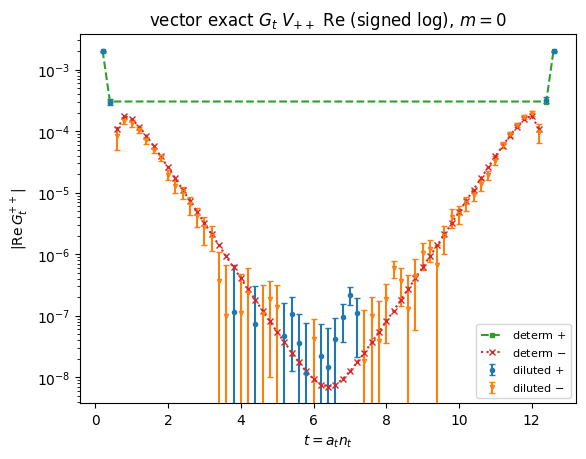

In [30]:
# vector exact $G_t$ $V_{++}$ Re on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d = prep_v('tp','Vpp')
v = m.real; e = ere; dv = d.real
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Re}\,G_t^{++}|$')
plt.title('vector exact $G_t$ $V_{++}$ Re (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/vec_exact_tp_pp_re_'+MLAB+'.pdf', bbox_inches='tight')


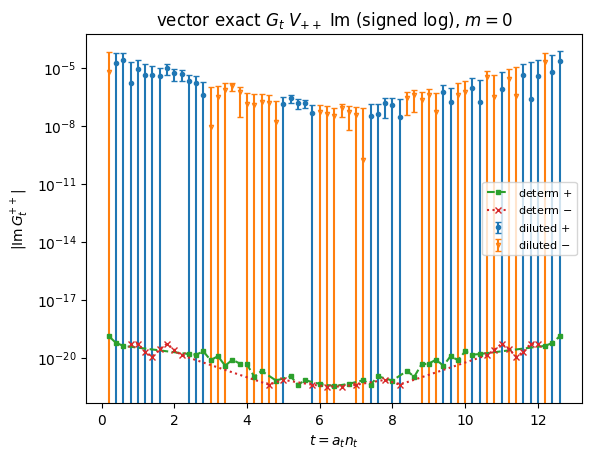

In [31]:
# vector exact $G_t$ $V_{++}$ Im on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d = prep_v('tp','Vpp')
v = m.imag; e = eim; dv = d.imag
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Im}\,G_t^{++}|$')
plt.title('vector exact $G_t$ $V_{++}$ Im (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/vec_exact_tp_pp_im_'+MLAB+'.pdf', bbox_inches='tight')


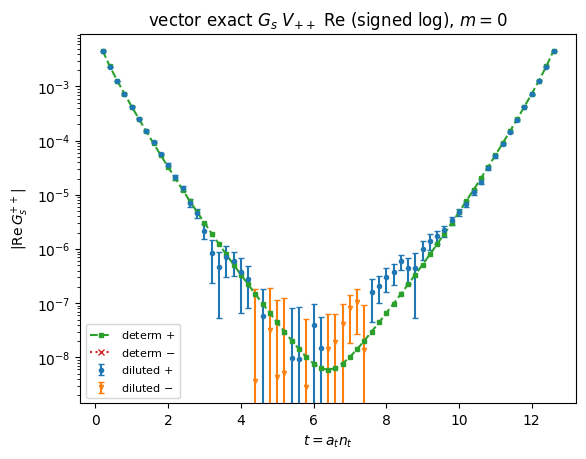

In [32]:
# vector exact $G_s$ $V_{++}$ Re on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d = prep_v('sp','Vpp')
v = m.real; e = ere; dv = d.real
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Re}\,G_s^{++}|$')
plt.title('vector exact $G_s$ $V_{++}$ Re (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/vec_exact_sp_pp_re_'+MLAB+'.pdf', bbox_inches='tight')


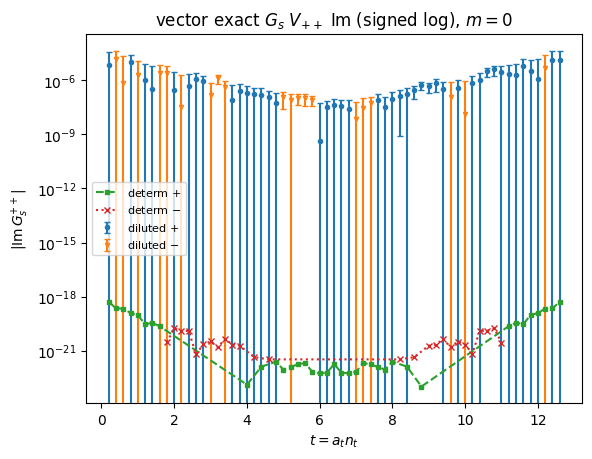

In [33]:
# vector exact $G_s$ $V_{++}$ Im on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d = prep_v('sp','Vpp')
v = m.imag; e = eim; dv = d.imag
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Im}\,G_s^{++}|$')
plt.title('vector exact $G_s$ $V_{++}$ Im (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/vec_exact_sp_pp_im_'+MLAB+'.pdf', bbox_inches='tight')


In [34]:
# # VECTOR exact ratio Gs/Gt (Re; normalization-free).  diluted (jk) vs determ.  LINEAR.  0<t<Nt/2.
# dt = np.arange(1, Nt_cft//2); t = dt*at_cft; ref = 5
# sp = half_shift_avg(dil_hits(DIL,'sp/Vpp')); tp = half_shift_avg(dil_hits(DIL,'tp/Vpp'))
# m,e = jk_ratio_re(sp, tp)
# plt.figure()
# plt.errorbar(t, m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label='diluted (jk)')
# ds = half_shift_avg(mirror(det_raw(EXS,'sp/Vpp'))).real; dtt = half_shift_avg(mirror(det_raw(EXS,'tp/Vpp'))).real
# plt.plot(t, (ds/dtt)[dt], 's--', ms=3, label='determ exact-K')
# plt.axhline(-1.0,color='k',lw=1,label='CFT $-1$'); plt.ylim(-3,0.5)
# plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$G_s/G_t$')
# plt.title('vector exact ratio $G_s/G_t$, $m='+MTIT+'$'); plt.legend(fontsize=8)
# plt.savefig(FIGDIR+'/vec_exact_ratio_'+MLAB+'.pdf', bbox_inches='tight')
# print('exact ratio @dt=%d: % .3f +- %.3f'%(ref,m[ref],e[ref]))


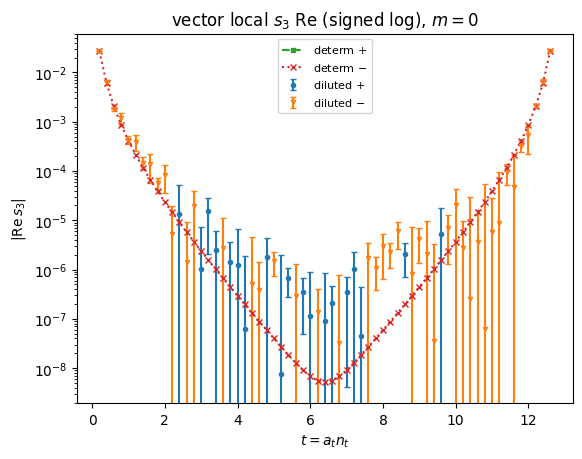

In [35]:
# vector local $s_3$ Re on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d = prep_loc(3)
v = m.real; e = ere; dv = d.real
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Re}\,s_3|$')
plt.title('vector local $s_3$ Re (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/vec_local_s3_re_'+MLAB+'.pdf', bbox_inches='tight')


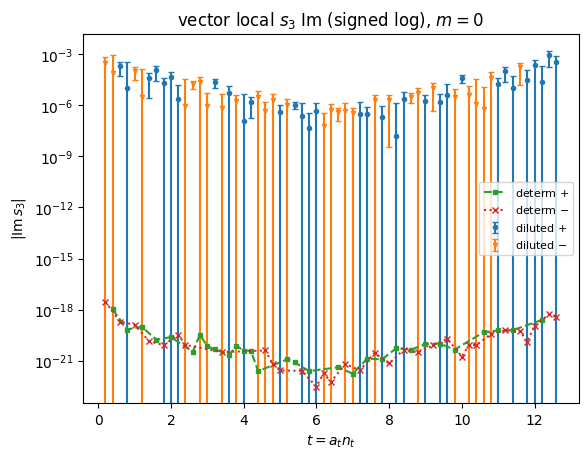

In [36]:
# vector local $s_3$ Im on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d = prep_loc(3)
v = m.imag; e = eim; dv = d.imag
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Im}\,s_3|$')
plt.title('vector local $s_3$ Im (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/vec_local_s3_im_'+MLAB+'.pdf', bbox_inches='tight')


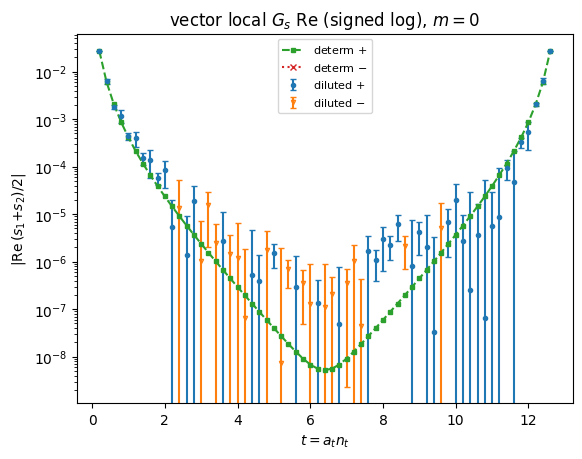

In [37]:
# vector local $G_s$ Re on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d = prep_locsp()
v = m.real; e = ere; dv = d.real
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Re}\,(s_1{+}s_2)/2|$')
plt.title('vector local $G_s$ Re (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/vec_local_sp_re_'+MLAB+'.pdf', bbox_inches='tight')


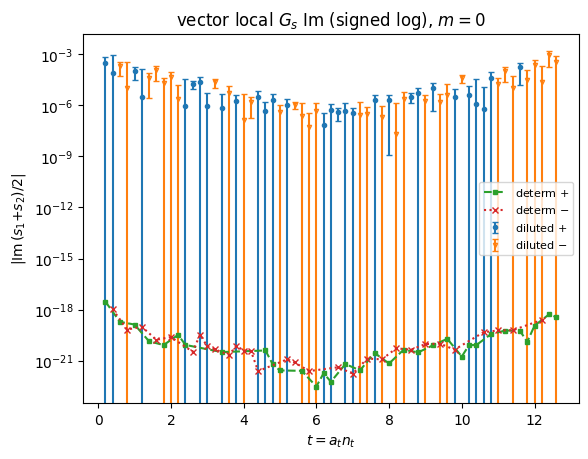

In [38]:
# vector local $G_s$ Im on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d = prep_locsp()
v = m.imag; e = eim; dv = d.imag
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Im}\,(s_1{+}s_2)/2|$')
plt.title('vector local $G_s$ Im (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/vec_local_sp_im_'+MLAB+'.pdf', bbox_inches='tight')


local ratio @dt=5: -1.000 +- 0.000


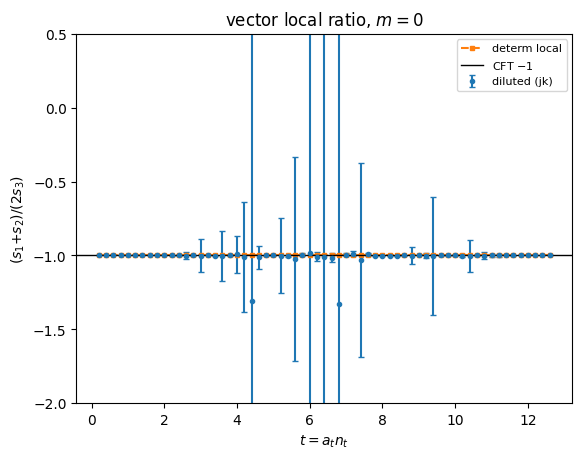

In [39]:
# VECTOR local ratio (s1+s2)/2 / s3 -> -1 (Re).  diluted (jk) vs determ.  LINEAR.  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft; ref = 5
num = 0.5*(half_shift_avg(dil_hits(DIL,'s1/Vpp'))+half_shift_avg(dil_hits(DIL,'s2/Vpp')))
den = half_shift_avg(dil_hits(DIL,'s3/Vpp'))
m,e = jk_ratio_re(num, den)
plt.figure()
plt.errorbar(t, m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label='diluted (jk)')
dn = 0.5*(half_shift_avg(mirror(det_raw(LOC,'s1/Vpp')))+half_shift_avg(mirror(det_raw(LOC,'s2/Vpp')))).real
dd = half_shift_avg(mirror(det_raw(LOC,'s3/Vpp'))).real
plt.plot(t, (dn/dd)[dt], 's--', ms=3, label='determ local')
plt.axhline(-1.0,color='k',lw=1,label='CFT $-1$'); plt.ylim(-2,0.5)
plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$(s_1{+}s_2)/(2 s_3)$')
plt.title('vector local ratio, $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/vec_local_ratio_'+MLAB+'.pdf', bbox_inches='tight')
print('local ratio @dt=%d: % .3f +- %.3f'%(ref,m[ref],e[ref]))


In [40]:
# # VECTOR local |s1| vs |s2| (free: spin-diagonal => s1==s2).  0<t<Nt/2, log.
# dt = np.arange(1, Nt_cft//2); t = dt*at_cft
# m1,_,_ = jk_cplx(half_shift_avg(dil_hits(DIL,'s1/Vpp'))); m2,_,_ = jk_cplx(half_shift_avg(dil_hits(DIL,'s2/Vpp')))
# plt.figure()
# plt.plot(t, np.abs(m1[dt]),'o',ms=3,label='$|s_1|$')
# plt.plot(t, np.abs(m2[dt]),'x',ms=4,label='$|s_2|$')
# plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|s_a|$')
# plt.title('vector local $s_1$ vs $s_2$, $m='+MTIT+'$'); plt.legend(fontsize=8)
# plt.savefig(FIGDIR+'/vec_local_s1s2_'+MLAB+'.pdf', bbox_inches='tight')
# print('max|s1-s2|/|s1| over dt:', np.max(np.abs(m1[dt]-m2[dt])/np.abs(m1[dt])))


In [41]:
# # VARIANCE: diluted vs volume error bars on -Re G_t (Nt/2-shift avg, log).  Volume run exists only for m0;
# # this cell auto-skips for mF/mP.  Matched cost ~ 1 diluted hit = 4 patterns ~ 4 volume hits.
# dt = np.arange(1, Nt_cft//2); t = dt*at_cft
# plt.figure()
# m,ere,eim,d = prep_v('tp','Vpp')
# plt.errorbar(t, -m.real[dt], yerr=ere[dt], fmt='o', ms=3, capsize=2, label='diluted (%d hits x4 patt)'%len(dil_files(DIL)))
# vfs = [f for f in sorted(glob.glob(ESN+VOL+'/corr.0.h*.h5')) if ('complete' in h5py.File(f,'r'))]
# if vfs:
#     vh=[]
#     for f in vfs:
#         with h5py.File(f,'r') as h:
#             bs=[k for k in h['h0'] if k.startswith('t0_')]; acc=None
#             for b in bs:
#                 v=h['h0/'+b+'/tp/Vpp/real'][()]+1j*h['h0/'+b+'/tp/Vpp/imag'][()]
#                 acc=v if acc is None else acc+v
#             vh.append(acc/len(bs))
#     mv,ev,_ = jk_cplx(half_shift_avg(np.array(vh)))
#     plt.errorbar(t+0.01, -mv.real[dt], yerr=ev[dt], fmt='s', ms=3, capsize=2, label='volume (%d hits)'%len(vh))
# else:
#     print('volume run not found (only m0 has it) -- diluted shown alone')
# plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$-\mathrm{Re}\,G_t$')
# plt.title('variance: diluted vs volume, $m='+MTIT+'$'); plt.legend(fontsize=8)
# plt.savefig(FIGDIR+'/vec_variance_'+MLAB+'.pdf', bbox_inches='tight')


In [42]:
# # VECTOR summary @dt=5 (Nt/2-shift avg, Re).  diluted vs determ.
# ref = 5
# mt,et,_ = jk_cplx(half_shift_avg(dil_hits(DIL,'tp/Vpp'))); ms,es,_ = jk_cplx(half_shift_avg(dil_hits(DIL,'sp/Vpp')))
# mr,er = jk_ratio_re(half_shift_avg(dil_hits(DIL,'sp/Vpp')), half_shift_avg(dil_hits(DIL,'tp/Vpp')))
# print('EXACT  @dt=%d:  G_t=% .3e +- %.1e   G_s=% .3e +- %.1e   G_s/G_t=% .3f +- %.3f'%(ref,mt.real[ref],et[ref],ms.real[ref],es[ref],mr[ref],er[ref]))
# dgt = half_shift_avg(mirror(EXS_SCALE*det_raw(EXS,'tp/Vpp'))).real; dgs = half_shift_avg(mirror(EXS_SCALE*det_raw(EXS,'sp/Vpp'))).real
# print('DETERM @dt=%d:  G_t=% .3e   G_s=% .3e   G_s/G_t=% .3f'%(ref,dgt[ref],dgs[ref],dgs[ref]/dgt[ref]))


## Axial current ($C_{A+-}$)
Exact-K axial `tp`/`sp` (`h0/axial/*/Apm`) and the local axial $s_3$.  Diluted (jk, $\times c=1/4\pi$) vs
determ exact1.  LOG axis; $+$ and $-$ sign branches of each Re/Im part in separate cells.  $0<t<N_t/2$.

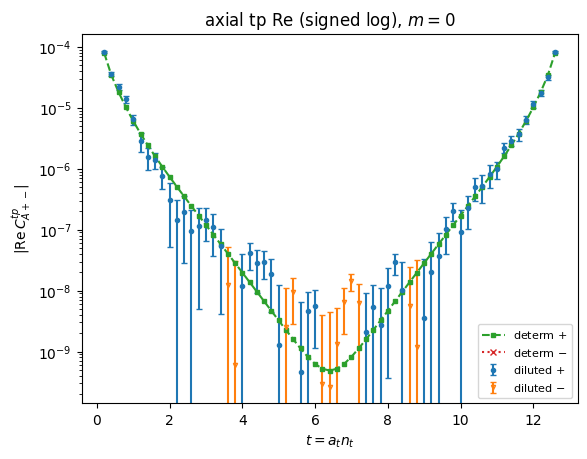

In [43]:
# axial tp Re on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d,c = prep_ax('tp')
v = (c*m).real; e = c*ere; dv = d.real
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Re}\,C_{A+-}^{tp}|$')
plt.title('axial tp Re (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/ax_exact_tp_re_'+MLAB+'.pdf', bbox_inches='tight')


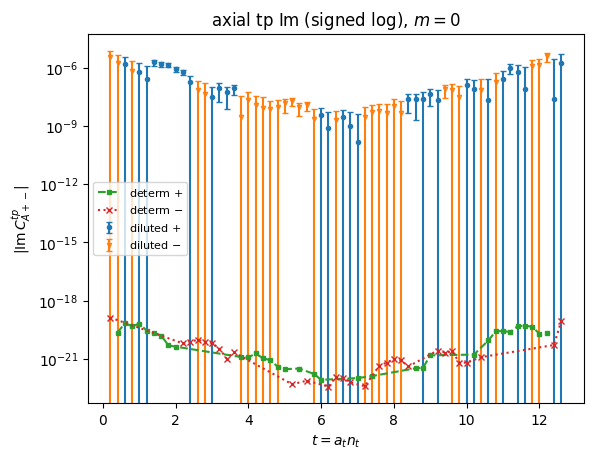

In [44]:
# axial tp Im on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d,c = prep_ax('tp')
v = (c*m).imag; e = c*eim; dv = d.imag
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Im}\,C_{A+-}^{tp}|$')
plt.title('axial tp Im (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/ax_exact_tp_im_'+MLAB+'.pdf', bbox_inches='tight')


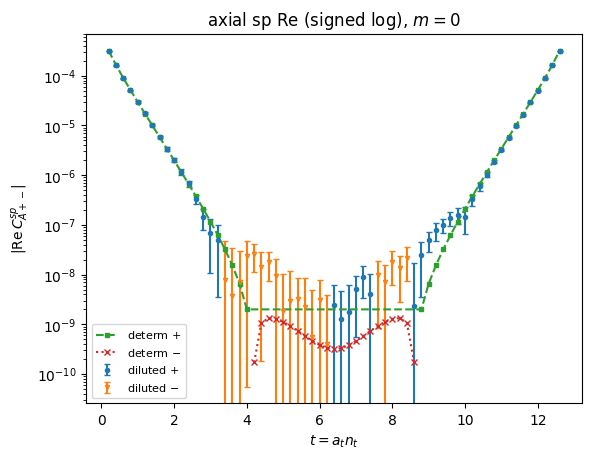

In [45]:
# axial sp Re on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d,c = prep_ax('sp')
v = (c*m).real; e = c*ere; dv = d.real
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Re}\,C_{A+-}^{sp}|$')
plt.title('axial sp Re (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/ax_exact_sp_re_'+MLAB+'.pdf', bbox_inches='tight')


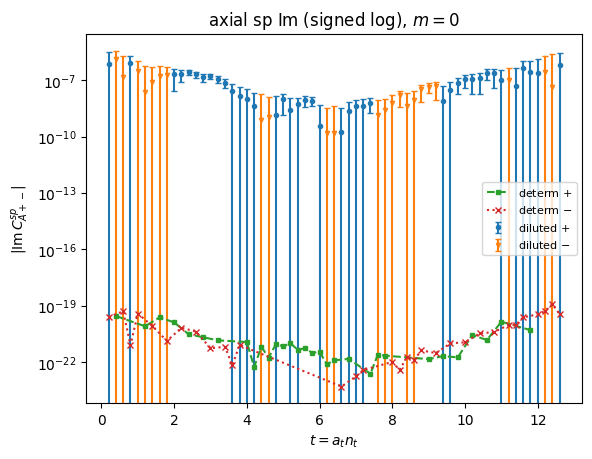

In [46]:
# axial sp Im on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d,c = prep_ax('sp')
v = (c*m).imag; e = c*eim; dv = d.imag
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Im}\,C_{A+-}^{sp}|$')
plt.title('axial sp Im (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/ax_exact_sp_im_'+MLAB+'.pdf', bbox_inches='tight')


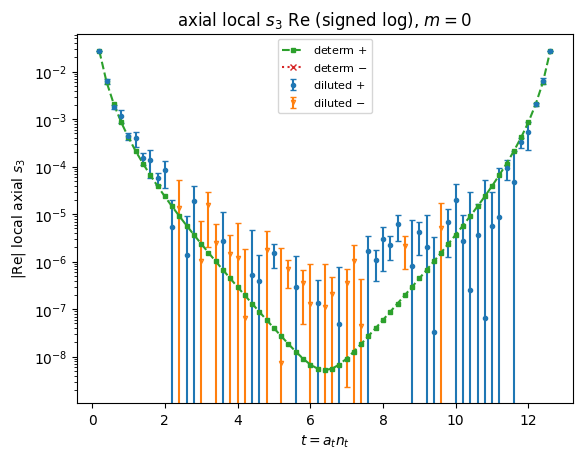

In [47]:
# axial local s3 Re on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
r = prep_axloc(3)
plt.figure()
if r is None:
    print('no diluted local axial')
else:
    m,ere,eim,d = r
    v = m.real; e = ere; dv = d.real
    pos = v[dt]>0; neg = v[dt]<0; dpos = dv[dt]>0; dneg = dv[dt]<0
    plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
    plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
    plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
    plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
    plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Re}|$ local axial $s_3$')
    plt.title('axial local $s_3$ Re (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
    plt.savefig(FIGDIR+'/ax_local_s3_re_'+MLAB+'.pdf', bbox_inches='tight')


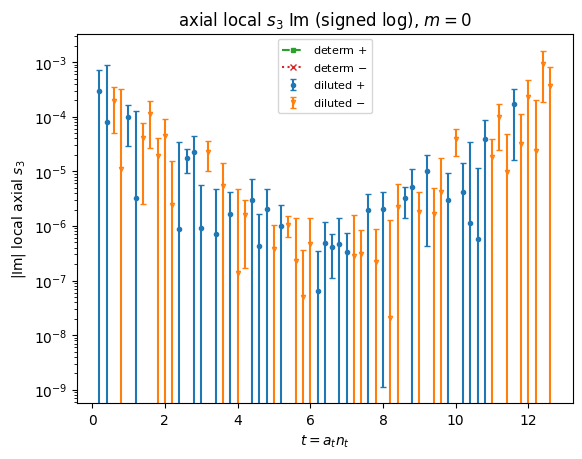

In [48]:
# axial local s3 Im on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
r = prep_axloc(3)
plt.figure()
if r is None:
    print('no diluted local axial')
else:
    m,ere,eim,d = r
    v = m.imag; e = eim; dv = d.imag
    pos = v[dt]>0; neg = v[dt]<0; dpos = dv[dt]>0; dneg = dv[dt]<0
    plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
    plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
    plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
    plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
    plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Im}|$ local axial $s_3$')
    plt.title('axial local $s_3$ Im (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
    plt.savefig(FIGDIR+'/ax_local_s3_im_'+MLAB+'.pdf', bbox_inches='tight')


In [49]:
# # AXIAL local ratio (s1+s2)/2 / s3 (Re).  diluted (jk) vs determ.  LINEAR.  0<t<Nt/2.
# dt = np.arange(1, Nt_cft//2); t = dt*at_cft
# A1,A2,A3 = dil_ax_loc(1), dil_ax_loc(2), dil_ax_loc(3)
# plt.figure()
# if A1 is None:
#     print('no diluted local axial')
# else:
#     rn,_,_ = jk_cplx(0.5*(half_shift_avg(A1)+half_shift_avg(A2))); rd,_,_ = jk_cplx(half_shift_avg(A3))
#     plt.plot(t, (rn.real/rd.real)[dt], 'o', ms=3, label='diluted local')
#     d1 = half_shift_avg(mirror(det_raw(LOCAX,'s1/Apm'))); d2 = half_shift_avg(mirror(det_raw(LOCAX,'s2/Apm'))); d3 = half_shift_avg(mirror(det_raw(LOCAX,'s3/Apm')))
#     plt.plot(t, ((0.5*(d1+d2)).real/d3.real)[dt], 's--', ms=3, label='determ local axial')
#     plt.axhline(-1.0,color='k',lw=1,label='$-1$'); plt.ylim(-3,1)
#     plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$(s_1{+}s_2)/(2 s_3)$ local axial')
#     plt.title('axial local ratio, $m='+MTIT+'$'); plt.legend(fontsize=8)
#     plt.savefig(FIGDIR+'/ax_local_ratio_'+MLAB+'.pdf', bbox_inches='tight')


In [50]:
# # AXIAL summary: diluted (x c) vs determ, Re and Im, both channels, a few dt.
# for proj in ['tp','sp']:
#     m,ere,eim,d,c = prep_ax(proj)
#     print('=== axial %s (c=%.4f) ===' % (proj, c))
#     for dt_ in [1,3,5,8,12]:
#         print(' dt%2d  Re dil % .3e+-%.1e det % .3e | Im dil % .3e+-%.1e det % .3e' % (
#             dt_, (c*m).real[dt_], c*ere[dt_], d.real[dt_], (c*m).imag[dt_], c*eim[dt_], d.imag[dt_]))


## Condensates ($\sigma_{PS}$ Eq. 1.23, $\sigma_{FS}$ Eq. 1.55)
Spacetime-averaged ($/V_{st}$) bilinears from `h0/condensate/*` (jk over hits) vs the DENSE exact reference
(`condensate_deter_L1`).  $\sigma_{PS}=$`etadag_xi`$+$`xidag_eta`, $\sigma_{FS}=$`etadag_xi`$-$`xidag_1mDdag_eta`.

In [51]:
# ----- condensate: dense ref + stochastic (jk) + table -----
DENSE = ESN + 'condensate_deter_L1/cond.h5'
STOCH = ESN + DIL + '/'
CKEYS = ['etadag_xi', 'xidag_eta', 'xidag_1mDdag_eta']
def cond_stoch(key):
    out=[]
    for fn in sorted(glob.glob(STOCH+'corr.0.h*.h5')):
        with h5py.File(fn,'r') as h:
            if 'complete' not in h: continue
            kk='h0/condensate/'+key
            out.append(h[kk+'/real'][()][0] + 1j*h[kk+'/imag'][()][0])
    return np.array(out)
def jk_scalar(a):
    H=len(a); s=a.sum()
    samp=np.array([(s-a[i])/(H-1) for i in range(H)])
    est=samp.mean(); vre=(H-1)*np.mean((samp.real-est.real)**2); vim=(H-1)*np.mean((samp.imag-est.imag)**2)
    return est, np.sqrt(vre), np.sqrt(vim)
with h5py.File(DENSE,'r') as f:
    Vst = f['Vst'][()][0]
    dense = {k: f['condensate/'+k+'/real'][()][0] + 1j*f['condensate/'+k+'/imag'][()][0] for k in CKEYS}
dense['sigma_PS'] = dense['etadag_xi'] + dense['xidag_eta']
dense['sigma_FS'] = dense['etadag_xi'] - dense['xidag_1mDdag_eta']
raw = {k: cond_stoch(k) for k in CKEYS}
nh = len(raw['etadag_xi']); assert nh > 0, 'no condensate hits in %s' % STOCH
raw['sigma_PS'] = raw['etadag_xi'] + raw['xidag_eta']
raw['sigma_FS'] = raw['etadag_xi'] - raw['xidag_1mDdag_eta']
print('condensate hits: %d   Vst=%.4f' % (nh, Vst))
print('%-18s %26s %26s' % ('quantity','stoch /Vst (re,im)','dense /Vst (re,im)'))
for k in CKEYS + ['sigma_PS','sigma_FS']:
    e,er,ei = jk_scalar(raw[k]); e,er,ei = e/Vst,er/Vst,ei/Vst; dd = dense[k]/Vst
    print('%-18s % .4e%+.4ej(+-%.0e,%.0e) % .4e%+.4ej' % (k,e.real,e.imag,er,ei,dd.real,dd.imag))


condensate hits: 49   Vst=1608.4954
quantity                   stoch /Vst (re,im)         dense /Vst (re,im)
etadag_xi          -1.0000e+00-1.4443e-04j(+-1e-12,6e-04) -1.0000e+00-4.6798e-18j
xidag_eta          -1.0000e+00+1.4443e-04j(+-1e-12,6e-04) -1.0000e+00+4.6798e-18j
xidag_1mDdag_eta    9.9994e-01+1.4443e-04j(+-8e-07,6e-04)  9.9994e-01+3.0163e-17j
sigma_PS           -2.0000e+00+0.0000e+00j(+-3e-12,0e+00) -2.0000e+00+0.0000e+00j
sigma_FS           -1.9999e+00-2.8885e-04j(+-8e-07,1e-03) -1.9999e+00-3.4843e-17j


(-1.9999999999574931+0j)


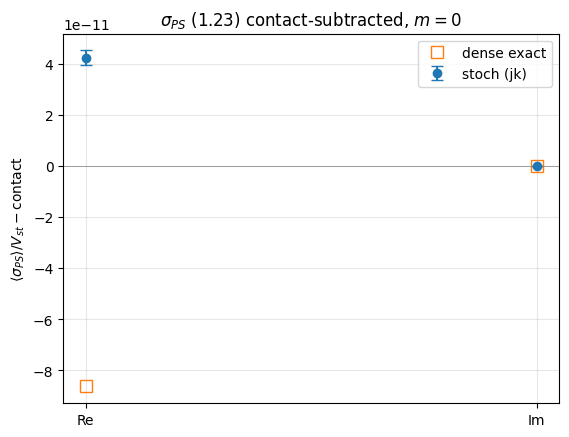

In [64]:
# CONDENSATE sigma_PS, CONTACT-SUBTRACTED (condensate_contact_massive_claude.md): sigma/Vst + |contact|.
e,er,ei = jk_scalar(raw['sigma_PS'])
m_cur = {'massless':0.0,'mF':0.1+0j,'mP':0.1j}[MASS]; csub = (1.0+1.0/(1.0+m_cur)) if MASS=='mP' else 2.0  # |contact|
dd = dense['sigma_PS']/Vst + csub
plt.figure()
print(e/Vst)

es = e/Vst + csub
plt.errorbar([0,1],[es.real,es.imag],yerr=[er/Vst,ei/Vst],fmt='o',capsize=4,label='stoch (jk)')
plt.plot([0,1],[dd.real,dd.imag],'s',ms=9,mfc='none',label='dense exact')
plt.axhline(0,color='gray',lw=0.5); plt.xticks([0,1],['Re','Im']); plt.ylabel(r'$\langle\sigma_{PS}\rangle/V_{st}-$contact')
plt.title(r'$\sigma_{PS}$ (1.23) contact-subtracted, $m='+MTIT+'$'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig(FIGDIR+'/cond_sigma_PS_sub_'+MLAB+'.pdf', bbox_inches='tight')


(-1.999937550167103-0.00028885131665781126j)


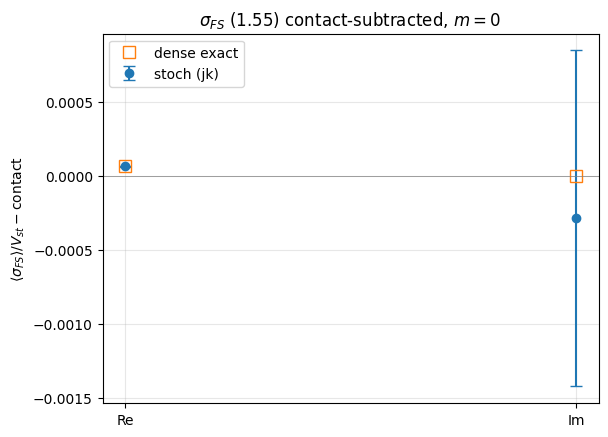

In [63]:
# CONDENSATE sigma_FS, CONTACT-SUBTRACTED (condensate_contact_massive_claude.md): sigma/Vst + |contact|.
e,er,ei = jk_scalar(raw['sigma_FS'])
m_cur = {'massless':0.0,'mF':0.1+0j,'mP':0.1j}[MASS]; csub = 2.0 if MASS=='massless' else (2.0-m_cur if MASS=='mF' else 2.0-(m_cur/(1.0+m_cur))**2)  # exact m.i. contact (md Sec 10): FS
dd = dense['sigma_FS']/Vst + csub
plt.figure()
print(e/Vst)

es = e/Vst + csub
plt.errorbar([0,1],[es.real,es.imag],yerr=[er/Vst,ei/Vst],fmt='o',capsize=4,label='stoch (jk)')
plt.plot([0,1],[dd.real,dd.imag],'s',ms=9,mfc='none',label='dense exact')
plt.axhline(0,color='gray',lw=0.5); plt.xticks([0,1],['Re','Im']); plt.ylabel(r'$\langle\sigma_{FS}\rangle/V_{st}-$contact')
plt.title(r'$\sigma_{FS}$ (1.55) contact-subtracted, $m='+MTIT+'$'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig(FIGDIR+'/cond_sigma_FS_sub_'+MLAB+'.pdf', bbox_inches='tight')


## Disconnected current ($C_\mathrm{disc}$) and physical sum
Disc post-processing (mirrors `jj_disc_postproc_claude.cc`; the C++ script reads the OLD multi-hit-per-file
layout, so for the dilute per-hit files it is done inline here): the disc one-point trace $J(t)$ is RAW
(no $1/4\pi$) per hit, and
$$C^P_\mathrm{disc}(\Delta t)=\tfrac{1}{4\pi}\,\tfrac{1}{N_t}\sum_{t_0}\bar J(t_0)\,\bar J(t_0+\Delta t),\quad
\bar J=\text{hit-average of }J.$$
For the FREE case ($U=1$, single config) the disc correlator is $\approx 0$ (noise floor $\sim1/N_\mathrm{hits}$).
The physical correlator is then $-C_\mathrm{conn}+C_\mathrm{disc}$ (PDF Eq. 3.39, vector only; conn $=V_{++}$
which carries its own $1/4\pi$).  Signed log, both branches, $0<t<N_t/2$.

In [54]:
# ----- disc post-processing (mirrors jj_disc_postproc_claude.cc) -----
INV4PI = 1.0/(4.0*np.pi)
def disc_J(proj, til=False):             # per-hit RAW one-point trace -> (nhits, Nt) complex
    key = 'h0/disc/%s/%s' % (proj, 'Jtil' if til else 'J')
    out=[]
    for f in dil_files(DIL):
        with h5py.File(f,'r') as h:
            out.append(h[key+'/real'][()] + 1j*h[key+'/imag'][()])
    return np.array(out)
def two_point(A, B):                     # (1/Nt) sum_t0 A[t0] B[(t0+dt) mod Nt] -> (Nt,) complex
    Nt=len(A); return np.array([np.mean(A*np.roll(B,-dt)) for dt in range(Nt)])
def prep_disc(proj, pm='Vpp'):           # disc two-point (jk over hits), Nt/2-shift'd -> (m, ere, eim)
    til = (pm=='Vmm' and parity); J = disc_J(proj, til=til); H=len(J); S=J.sum(0)
    samp=[]
    for i in range(H):
        jb=(S-J[i])/(H-1); c=INV4PI*two_point(jb,jb)
        if pm=='Vmm' and not parity: c=np.conj(c)
        samp.append(half_shift_avg(c))
    samp=np.array(samp); est=samp.mean(0)
    ere=np.sqrt((H-1)*np.mean((samp.real-est.real)**2,0)); eim=np.sqrt((H-1)*np.mean((samp.imag-est.imag)**2,0))
    return est, ere, eim
def prep_phys(proj):                     # physical = -C_conn + C_disc (Eq 3.39, vector V++), Nt/2-shift'd.
    # SINGLE delete-1 jackknife over hits: each pseudo-value recomputes BOTH the conn mean and the
    # (quadratic) disc two-point on the SAME leave-one-out hit set, so the error carries the disc variance
    # AND the conn-disc covariance (disc is NOT added as a fixed constant -- that undercounts the error).
    conn = half_shift_avg(dil_hits(DIL, proj+'/Vpp')); J = disc_J(proj)
    H = len(conn); Sc = conn.sum(0); SJ = J.sum(0)
    samp = []
    for i in range(H):
        Jbar_i = (SJ - J[i])/(H-1)
        samp.append(-(Sc - conn[i])/(H-1) + half_shift_avg(INV4PI*two_point(Jbar_i, Jbar_i)))
    samp = np.array(samp); est = samp.mean(0)
    ere = np.sqrt((H-1)*np.mean((samp.real-est.real)**2,0))
    eim = np.sqrt((H-1)*np.mean((samp.imag-est.imag)**2,0))
    d = -half_shift_avg(mirror(EXS_SCALE*det_raw(EXS, proj+'/Vpp')))   # -conn determ (+ disc determ = 0 free)
    return est, ere, eim, d
print('disc one-point hits:', len(dil_files(DIL)))


disc one-point hits: 49


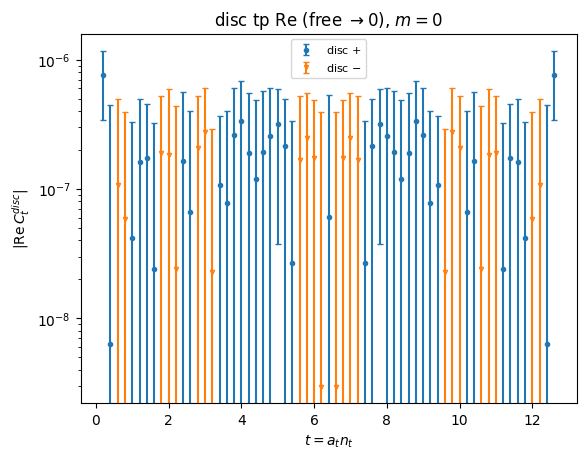

In [55]:
# DISC two-point tp V++ Re on signed-log (free -> ~0 noise floor).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim = prep_disc('tp')
v = m.real; e = ere
pos = v[dt] > 0; neg = v[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='disc $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='disc $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Re}\,C^{disc}_{t}|$')
plt.title('disc tp Re (free $\\to 0$), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/disc_tp_re_'+MLAB+'.pdf', bbox_inches='tight')


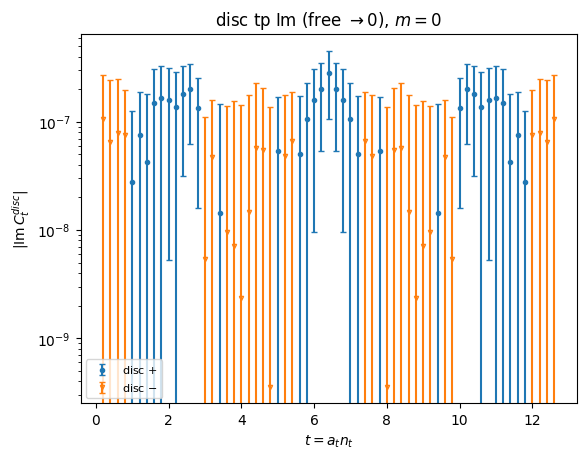

In [56]:
# DISC two-point tp V++ Im on signed-log (free -> ~0 noise floor).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim = prep_disc('tp')
v = m.imag; e = eim
pos = v[dt] > 0; neg = v[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='disc $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='disc $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Im}\,C^{disc}_{t}|$')
plt.title('disc tp Im (free $\\to 0$), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/disc_tp_im_'+MLAB+'.pdf', bbox_inches='tight')


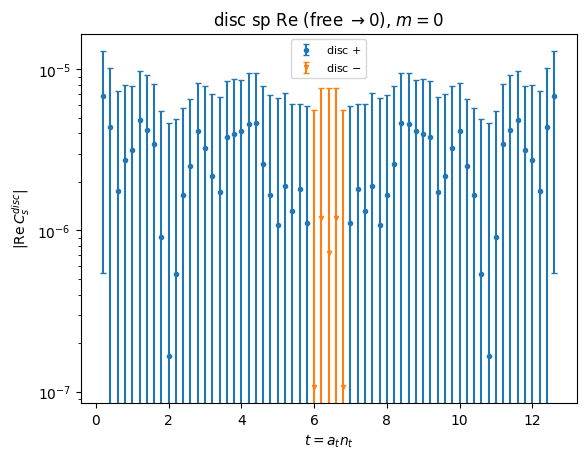

In [57]:
# DISC two-point sp V++ Re on signed-log (free -> ~0 noise floor).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim = prep_disc('sp')
v = m.real; e = ere
pos = v[dt] > 0; neg = v[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='disc $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='disc $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Re}\,C^{disc}_{s}|$')
plt.title('disc sp Re (free $\\to 0$), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/disc_sp_re_'+MLAB+'.pdf', bbox_inches='tight')


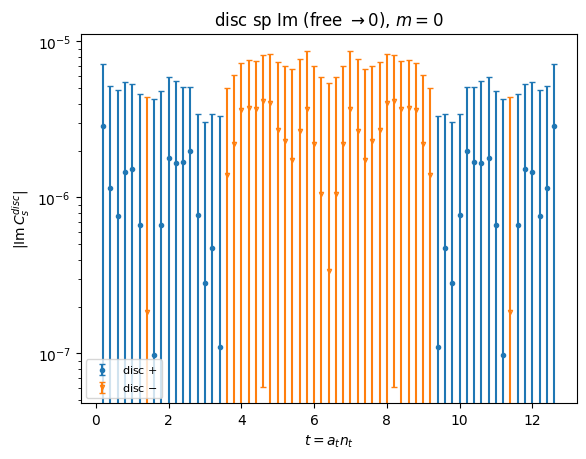

In [58]:
# DISC two-point sp V++ Im on signed-log (free -> ~0 noise floor).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim = prep_disc('sp')
v = m.imag; e = eim
pos = v[dt] > 0; neg = v[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='disc $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='disc $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Im}\,C^{disc}_{s}|$')
plt.title('disc sp Im (free $\\to 0$), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/disc_sp_im_'+MLAB+'.pdf', bbox_inches='tight')


### Physical sum $-C_\mathrm{conn}+C_\mathrm{disc}$ (Eq. 3.39, vector)
Conn $=V_{++}$ exact-K (diluted); disc $\approx0$ for free, so the physical correlator $\approx -C_\mathrm{conn}$
(sign flips relative to conn: $G_t$ becomes positive, $G_s$ negative).  Determ overlay $=-C_\mathrm{conn}^\mathrm{determ}$.

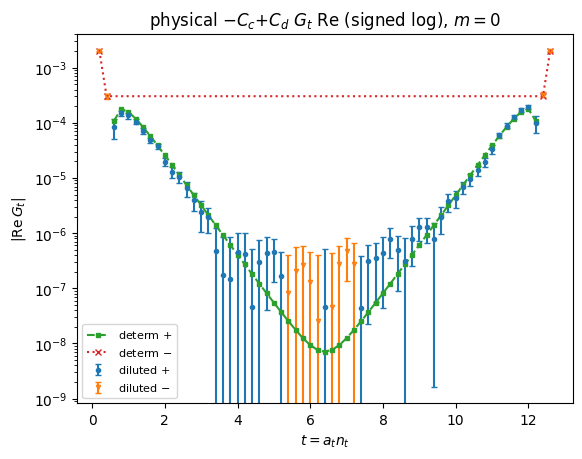

In [59]:
# physical $-C_c{+}C_d$ $G_t$ Re on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d = prep_phys('tp')
v = m.real; e = ere; dv = d.real
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Re}\,G_t|$')
plt.title('physical $-C_c{+}C_d$ $G_t$ Re (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/phys_tp_re_'+MLAB+'.pdf', bbox_inches='tight')


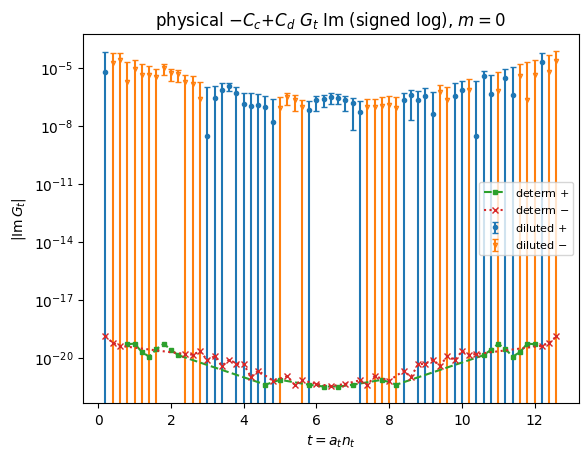

In [60]:
# physical $-C_c{+}C_d$ $G_t$ Im on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d = prep_phys('tp')
v = m.imag; e = eim; dv = d.imag
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Im}\,G_t|$')
plt.title('physical $-C_c{+}C_d$ $G_t$ Im (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/phys_tp_im_'+MLAB+'.pdf', bbox_inches='tight')


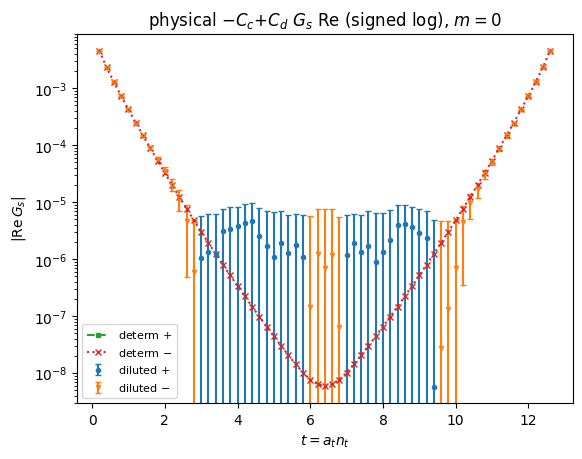

In [61]:
# physical $-C_c{+}C_d$ $G_s$ Re on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d = prep_phys('sp')
v = m.real; e = ere; dv = d.real
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Re}\,G_s|$')
plt.title('physical $-C_c{+}C_d$ $G_s$ Re (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/phys_sp_re_'+MLAB+'.pdf', bbox_inches='tight')


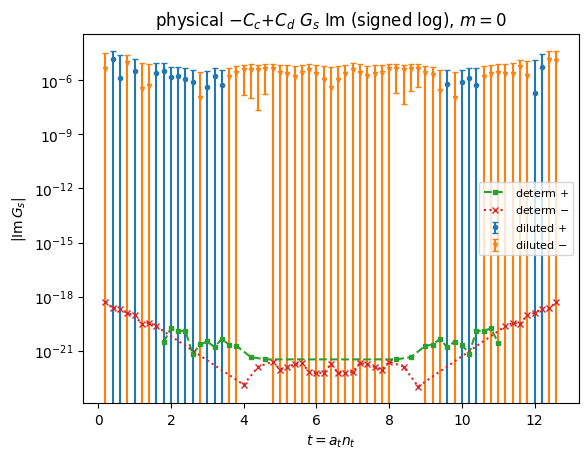

In [62]:
# physical $-C_c{+}C_d$ $G_s$ Im on signed-log (both sign branches; diluted vs determ).  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m,ere,eim,d = prep_phys('sp')
v = m.imag; e = eim; dv = d.imag
pos = v[dt] > 0; neg = v[dt] < 0; dpos = dv[dt] > 0; dneg = dv[dt] < 0
plt.figure()
plt.errorbar(t[pos], v[dt][pos], yerr=e[dt][pos], fmt='o', ms=3, capsize=2, label='diluted $+$')
plt.errorbar(t[neg], -v[dt][neg], yerr=e[dt][neg], fmt='v', ms=3, capsize=2, mfc='none', label='diluted $-$')
plt.plot(t[dpos], dv[dt][dpos], 's--', ms=3, label='determ $+$')
plt.plot(t[dneg], -dv[dt][dneg], 'x:', ms=4, label='determ $-$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|\mathrm{Im}\,G_s|$')
plt.title('physical $-C_c{+}C_d$ $G_s$ Im (signed log), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/phys_sp_im_'+MLAB+'.pdf', bbox_inches='tight')
